# *Breast Cancer Detection Using Deep Learning (Fuzzy)*

# 01 - Data Exploration

Purpose:
- Load raw breast thermogram images
- Visualize sample images
- Inspect image size, channels and intensity range
- Verify dataset structure

Dataset(s):
- DMR-IR

In [1]:
import sys, os
import numpy as np

In [2]:
sys.path.append(os.path.abspath(".."))

In [3]:
from src.sch_cs import run_schcs, SchCsStorageConfig
from src.chm_bias_correction import CHMConfig, CHMCorrector
from src.preprocessing import StorageConfig, run_preprocessing
from src.level_set_initialization import PhiInitConfig, LevelSetInitializer
from src.utils import PRE_CFG, SCH_CFG, load_schcs_results, load_preprocessing_results
from src.utils import (
    base_path,
    dmr_ir_o,
    schcs_results_path,
    preprocessed_results_path,
    chm_corrected_results_path,
    phi_initialized_result_path,
)

## PRE-PROCESSING

In [4]:
DMR_IR_PATH = base_path + dmr_ir_o

image_files = sorted([
    f for f in os.listdir(DMR_IR_PATH)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])
print(f'Found {len(image_files)} images:')
for i, f in enumerate(image_files):
    print(f'  [{i}] {f}')

Found 17 images:
  [0] TFRON_V11_31-10-2012_0.jpg
  [1] TFRON_V12_31-10-2012_0.jpg
  [2] TFRON_V13_31-10-2012_0.jpg
  [3] TFRON_V15_31-10-2012_0.jpg
  [4] TFRON_V16_31-10-2012_0.jpg
  [5] TFRON_V1_26-10-2012_0.jpg
  [6] TFRON_V243_12-3-2014_0.jpg
  [7] TFRON_V247_21-5-2014_0.jpg
  [8] TFRON_V2_30-10-2012_0.jpg
  [9] TFRON_V39_7-11-2012_0.jpg
  [10] TFRON_V4_30-10-2012_0.jpg
  [11] TFRON_V59_20-11-2012_0.jpg
  [12] TFRON_V5_30-10-2012_0.jpg
  [13] TFRON_V6_30-10-2012_0.jpg
  [14] TFRON_V7_31-10-2012_0.jpg
  [15] TFRON_V8_31-10-2012_0.jpg
  [16] TFRON_V9_31-10-2012_0.jpg


In [5]:
IMAGE_INDEX = 6   # ← change this to try a different image
IMAGE_PATH  = os.path.join(DMR_IR_PATH, image_files[IMAGE_INDEX])

  PRE-PROCESSING: TFRON_V243_12-3-2014_0.jpg
[1.0] Loaded 480×640.
[1.1] FLIR overlay zeroed: top 38px.
[1.2] No colour bar detected.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=3px, bbox=(1×1), aspect=1.00.
[1.2] Calibration square removed: size=1px, bbox=(0×0), aspect=0.00.
[1.2] Calibration square removed: size

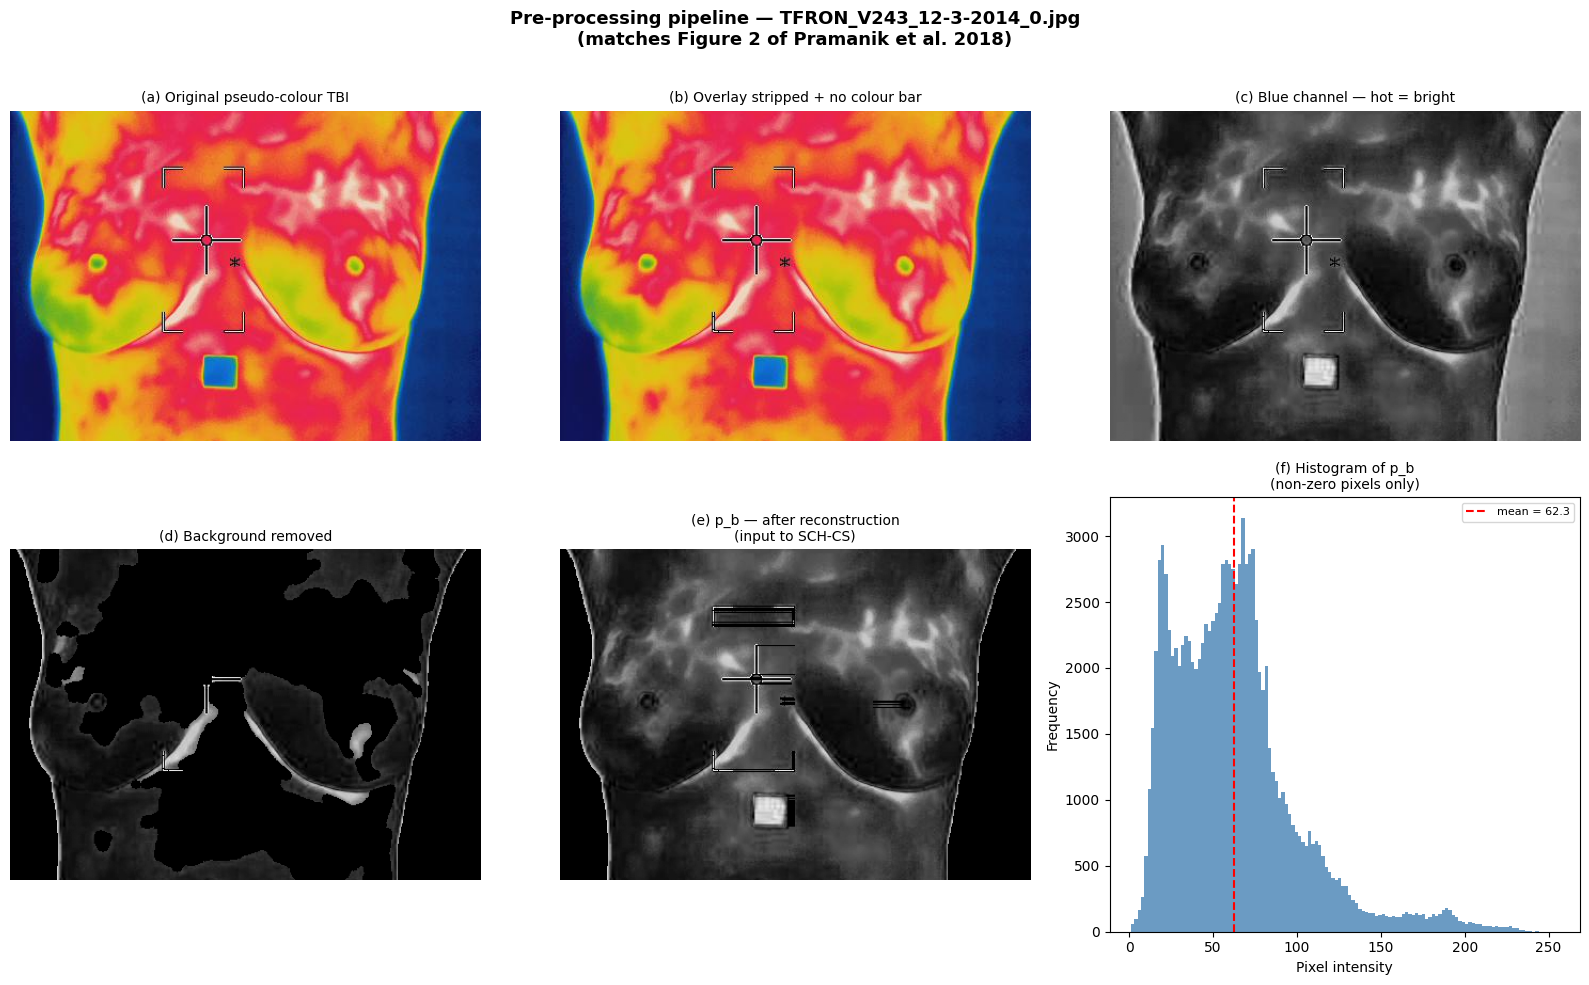

[Save] p_b saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260410_225008\TFRON_V243_12-3-2014_0_pb.png
[Save] Grayscale saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260410_225008\TFRON_V243_12-3-2014_0_grayscale.png
[Save] Background removed saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260410_225008\TFRON_V243_12-3-2014_0_bg_removed.png
[Save] Original color saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260410_225008\TFRON_V243_12-3-2014_0_original_color.png
[Save] Metadata saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260410_225008\TFRON_V243_12-3-2014_0_metadata.json

Results saved to: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260410_225008
p_b saved at: ..\data\preprocessed\TFRON_V243_12-3-2014_0_20260410_225008\TFRON_V243_12-3-2014_0_pb.png


In [6]:
preprocessing_results = run_preprocessing(
    image_path=IMAGE_PATH,
    cfg=PRE_CFG,
    visualize=True,
    save_results=True,
    storage_config=StorageConfig(output_dir=preprocessed_results_path)
)

# PREPROCESSING RESULTS
print(f"\nResults saved to: {preprocessing_results['run_dir']}")
print(f"p_b saved at: {preprocessing_results['saved_paths']['pb']}")

In [7]:
# lOADING PRE-PROCESSING RESULTS FOR NEXT STEPS:
preprocessing_results_loaded = load_preprocessing_results(preprocessing_results['run_dir'])
pb = preprocessing_results_loaded['pb']
image_name = preprocessing_results_loaded['base_name']
print(image_name)

[Load] Loaded preprocessing results for: TFRON_V243_12-3-2014_0
pb shape: (310, 441)
TFRON_V243_12-3-2014_0


## SCH-CS


  SCH-CS: TFRON_V243_12-3-2014_0

[SCH 2.1] Building histogram...
  N=109330, R=242, m=N/R=451.78, peaks found=63

[SCH 2.2] Computing rho...
  r=22, V=1258.0, C=86.9, max_h=1732 at level 73
  rho=-431.85 (fallback to m) → rho_eff=451.78

[SCH 2.3] Computing t*...
  |A|=41, A range=[98,243], m(A)=171.10, alpha(A)=42.05, t*=129.05

[SCH 2.4] Computing th...
  m(p)=62.32, t*=129.05 → th = t* = 129.05

[SCH 2.5] Thresholding (th=129.05) and labelling...
  SR pixels=5846, regions total=94, after size filter=24

[CS 2.7] Weighted centroids for 24 regions...
  R(   1): centroid=(153.3,29.4), size=575px
  R(  14): centroid=(79.5,330.0), size=986px
  R(  15): centroid=(54.1,151.1), size=21px
  R(  17): centroid=(78.3,284.3), size=553px
  R(  19): centroid=(72.4,117.7), size=191px
  R(  22): centroid=(73.9,364.8), size=73px
  R(  34): centroid=(82.0,86.5), size=29px
  R(  40): centroid=(102.5,182.1), size=30px
  R(  44): centroid=(104.0,185.0), size=27px
  R(  46): centroid=(104.8,157.6), size

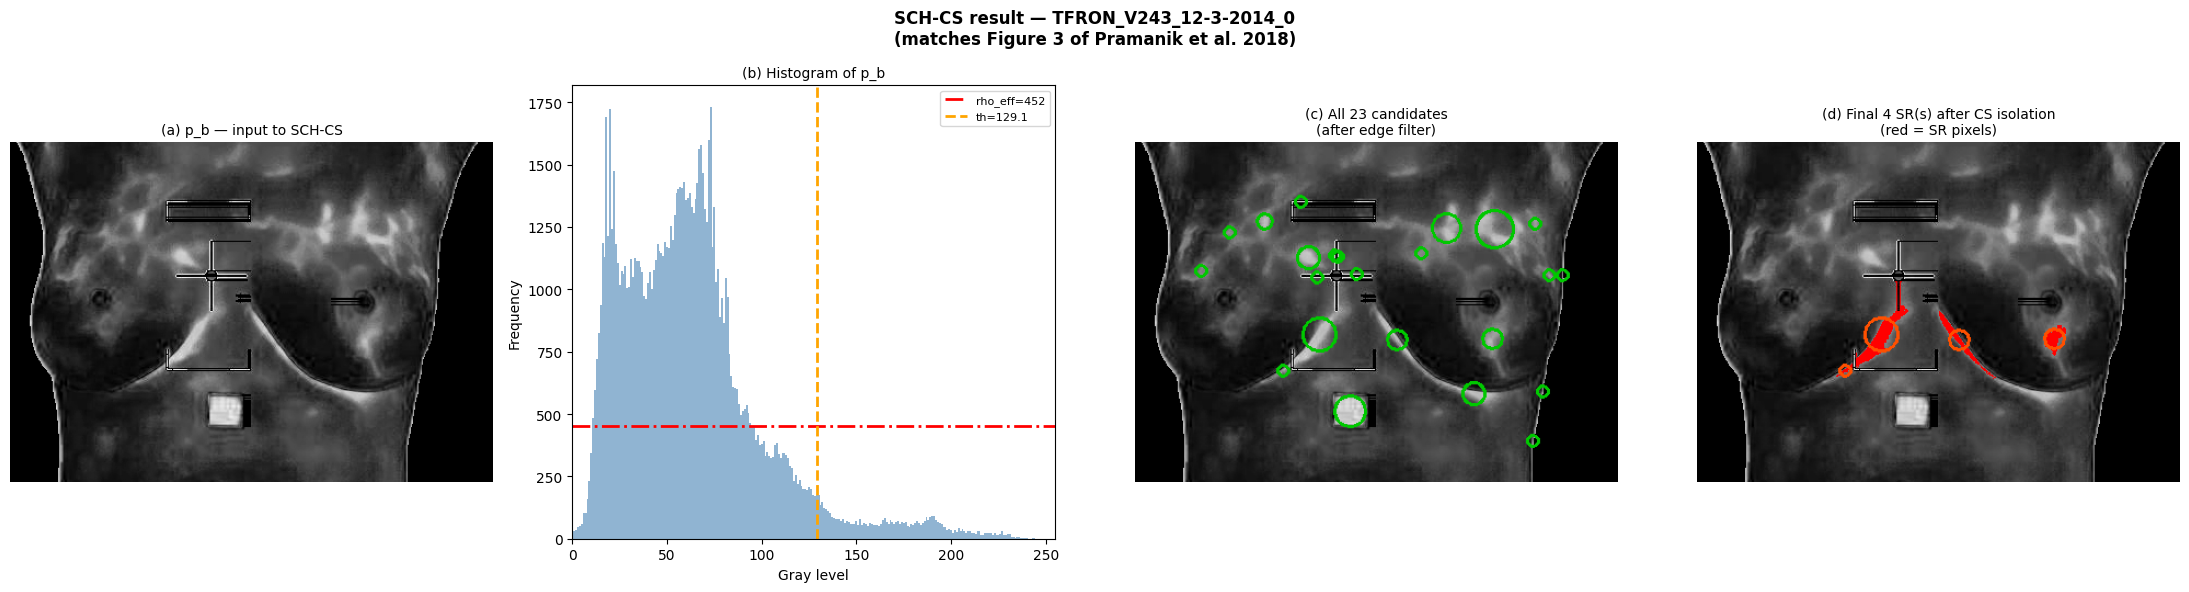


 Final SR summary:
  Label    Size(px)   Centroid(row,col)
  -------- ---------- --------------------
  65       718        (174.7, 168.4)
  67       284        (180.0, 239.0)
  69       259        (178.9, 326.3)
  79       45         (207.6, 135.3)

[Done] 4 SR(s) ready for DLPE Level Set.
[Save] Binary image saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260410_225032\TFRON_V243_12-3-2014_0_binary.png
[Save] SR mask saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260410_225032\TFRON_V243_12-3-2014_0_sr_mask.png
[Save] Labeled image saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260410_225032\TFRON_V243_12-3-2014_0_labeled.png
[Save] Regions data saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260410_225032\TFRON_V243_12-3-2014_0_regions.pkl
[Save] Metadata saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260410_225032\TFRON_V243_12-3-2014_0_metadata.json

Results saved to: ..\data\sch_cs\TFRON_V243_12-3-2014_0_20260410_225032
Binary image (for Level Set) saved at: ..\data

In [8]:
schcs_result = run_schcs(
    pb=pb,
    cfg=SCH_CFG,
    visualize=True,
    image_name=image_name,
    save_results=True,
    storage_config=SchCsStorageConfig(output_dir=schcs_results_path)
)

# SCH-CS RESULTS
print(f"\nResults saved to: {schcs_result['run_dir']}")
print(f"Binary image (for Level Set) saved at: {schcs_result['saved_paths']['binary_image']}")

In [9]:
# GLOBAL DICTIONARY
schcs_runs = {}

# TRACKING DICTIONARY
schcs_runs[image_name] = {
    'run_dir': schcs_result['run_dir'],
    'timestamp': schcs_result['timestamp'],
    'num_regions': len(schcs_result['sr_regions'])
}

# SCH-CS RESULTS FOR LEVEL SET
schcs_results_loaded  = load_schcs_results(schcs_runs[image_name]['run_dir'])
p_th_b = schcs_results_loaded['binary_image']  # This is p_th_b for Eq 17

[Load] Binary image loaded: (310, 441)
[Load] SR mask loaded: (310, 441)
[Load] Regions data loaded
[Load] Loaded SCH-CS results for: TFRON_V243_12-3-2014_0
       Number of SR regions: 4


## CHM Bias Correction


CHM Bias Field Correction - Stage 2

[Init] Output directory ready: ..\data\chm_corrected
[CHM] Input pb: shape=(310, 441), dtype=uint8, range=[0,244]
[Eq 9]  Nc = 85.0417
[Eq 10] p_bar range: [0.000, 214.599]
[CHM] p_bar : shape=(310, 441), dtype=float64
[CHM] ✓ p_bar ready.
[Save] Corrected image saved → ..\data\chm_corrected\TFRON_V243_12-3-2014_0_20260410_225051.png
[CHM] Corrected image saved to: ..\data\chm_corrected\TFRON_V243_12-3-2014_0_20260410_225051.png


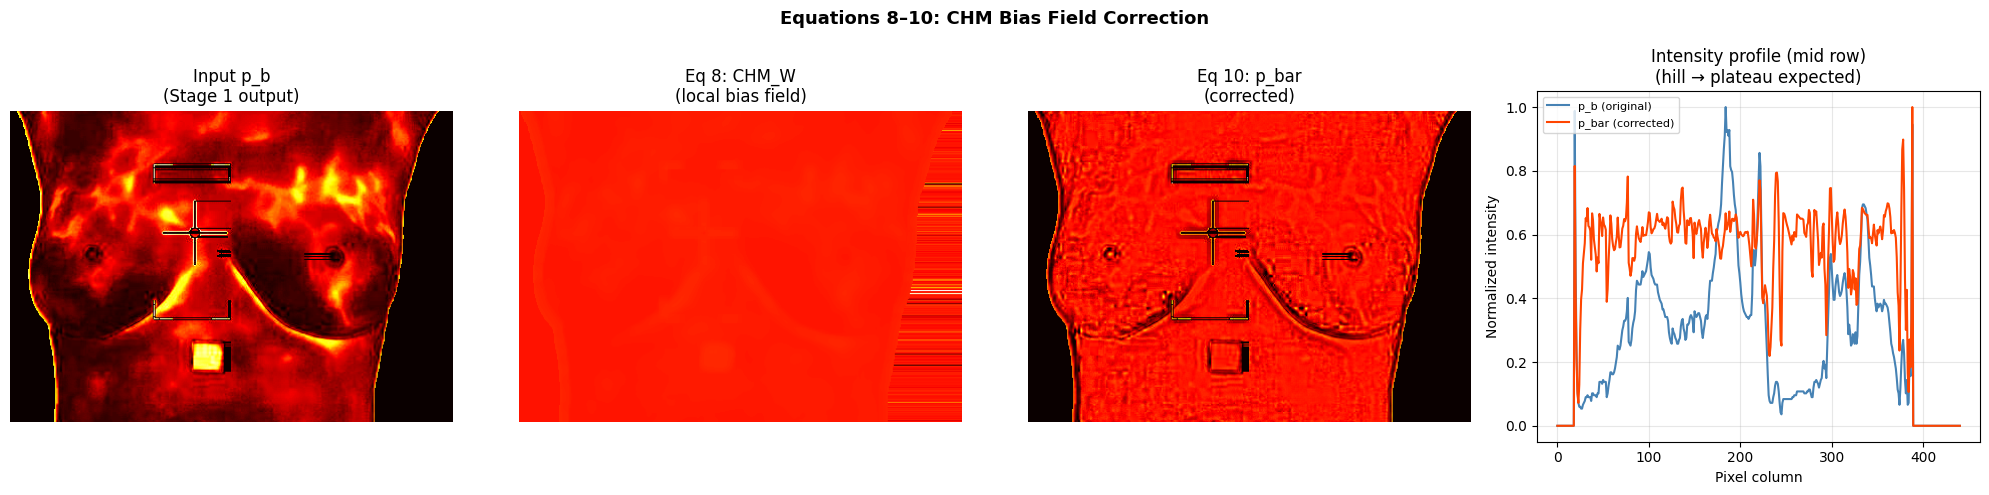


--- Verification ---
p_bar shape: (310, 441)
p_bar dtype: float64
p_bar range: [0.000, 214.599]
p_bar mean: 64.113
p_bar std: 34.750

[Ready] p_bar computed successfully.
[Ready] Corrected image saved to: ..\data\chm_corrected/
Next step → Initialize φ using SCH-CS blobs (Eq 17),
then start the DLPE Level Set iteration loop.


In [10]:
print("\n" + "="*60)
print("CHM Bias Field Correction - Stage 2")
print("="*60 + "\n")

# CHM CONFIGURATION
config = CHMConfig(
    order=1,
    window_size=9,
    show_visualization= True,
    save_visualization= False,
    save_corrected_image=True,
    output_dir=chm_corrected_results_path,
    visualization_path="chm_correction_result.png",
)

# INITIALIZE CORRECTOR
corrector = CHMCorrector(config)

try:
    if 'pb' in dir() or 'pb' in globals():
        p_bar = corrector.process(pb, image_name=image_name, visualize=True, save_image=True)
        
        print("\n--- Verification ---")
        print(f"p_bar shape: {p_bar.shape}")
        print(f"p_bar dtype: {p_bar.dtype}")
        print(f"p_bar range: [{p_bar.min():.3f}, {p_bar.max():.3f}]")
        print(f"p_bar mean: {p_bar.mean():.3f}")
        print(f"p_bar std: {p_bar.std():.3f}")
        
        print("\n[Ready] p_bar computed successfully.")
        print(f"[Ready] Corrected image saved to: {config.output_dir}/")
        print("Next step → Initialize φ using SCH-CS blobs (Eq 17),")
        print("then start the DLPE Level Set iteration loop.")
    else:
        print("Error: 'pb' variable not found. Please load your preprocessed image first.")
        
except Exception as e:
    print(f"Error: {e}")

## LEVEL SET INITIALIZATION


Level Set Function φ Initialization - Stage 2 Step 2

[Init] Output directory ready: ..\data\phi_initialized
[Load]  Preprocessed TBI shape  : (310, 441)
[Load]  SCH-CS binary blob shape: (310, 441)

[Process] Initializing φ for: TFRON_V243_12-3-2014_0_pb
          Input shape: (310, 441)
[Init]  Binary image normalized from [0,255] → [0.0, 1.0]
[Eq 17] φ initialized successfully.
        Shape      : (310, 441)
        Inside SR  : 5846 pixels (4.3%) → φ = +4.0
        Outside SR : 130864 pixels (95.7%) → φ = -4.0
        φ unique values: [-4.  4.]
[Save] φ array saved → ..\data\phi_initialized\TFRON_V243_12-3-2014_0_pb_phi_20260410_225116.npy
[Save] Visualization saved → ..\data\phi_initialized\TFRON_V243_12-3-2014_0_pb_phi_viz_20260410_225116.png


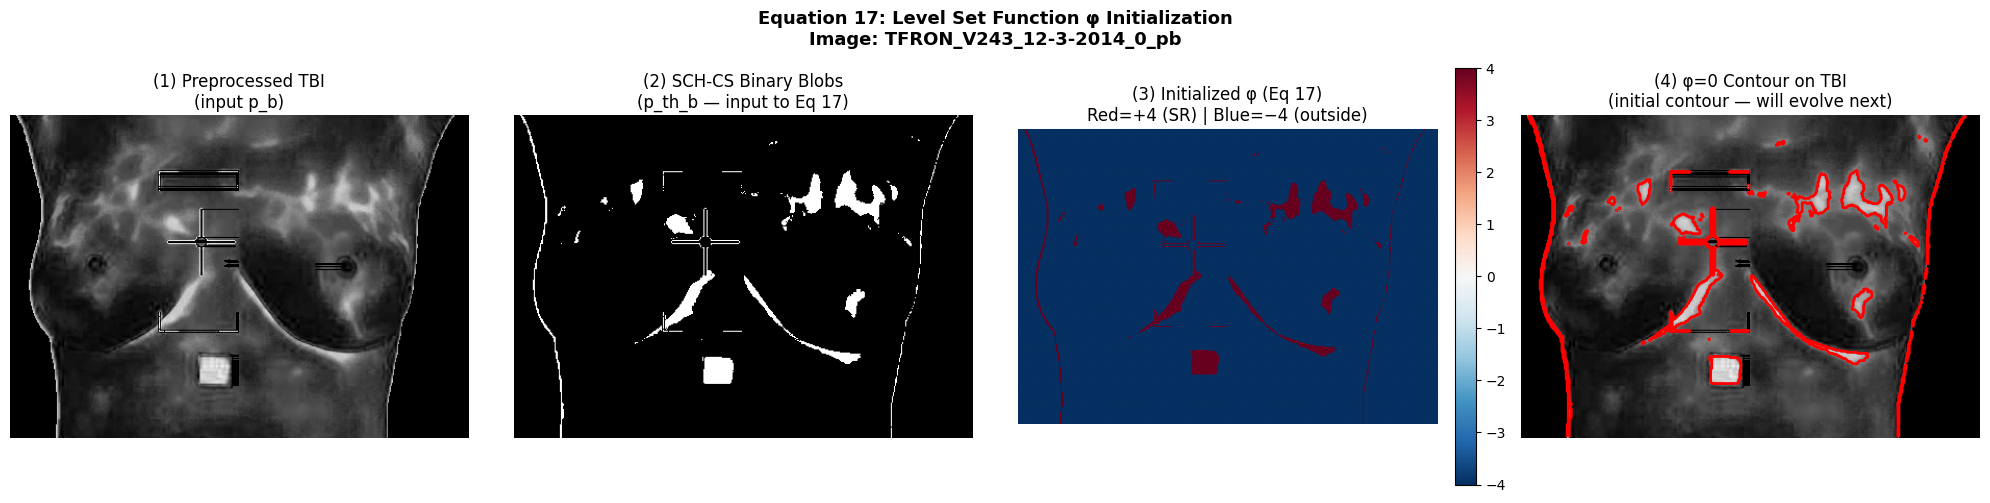


--- Verification ---
phi shape: (310, 441)
phi dtype: float64
phi values: [-4.  4.]   ← should be [-4. +4.]

[Ready] φ initialized successfully.
φ array saved to: ..\data\phi_initialized\TFRON_V243_12-3-2014_0_pb_phi_20260410_225116.npy

What you have now:
✅ p_bar — from chm_correction.py  (Eq 10)
✅ phi — just computed (Eq 17)
→ Next: DLPE iteration loop (Eq 18, 19, 20, 21)


In [11]:
print("\n" + "="*60)
print("Level Set Function φ Initialization - Stage 2 Step 2")
print("="*60 + "\n")

# Example paths (update with your actual paths)
PREPROCESSED_PATH = preprocessing_results['saved_paths']['pb']
SCHCS_BINARY_PATH = schcs_result['saved_paths']['binary_image']
OUTPUT_DIR = phi_initialized_result_path

# Create configuration
config = PhiInitConfig(
    inside_value=4.0,
    outside_value=-4.0,
    save_visualization=True,
    show_visualization=True,
    output_dir=OUTPUT_DIR,
    save_phi_array=True
)

# Initialize processor
initializer = LevelSetInitializer(config)

# Process from files
try:
    phi = initializer.process_from_files(
        preprocessed_image_path=PREPROCESSED_PATH,
        schcs_binary_path=SCHCS_BINARY_PATH,
        visualize=True
    )
    
    # Print results
    print("\n--- Verification ---")
    print(f"phi shape: {phi.shape}")
    print(f"phi dtype: {phi.dtype}")
    print(f"phi values: {np.unique(phi)}   ← should be [-4. +4.]")
    
    results = initializer.get_results()
    print(f"\n[Ready] φ initialized successfully.")
    print(f"φ array saved to: {results['saved_filepath']}")
    print("\nWhat you have now:")
    print("✅ p_bar — from chm_correction.py  (Eq 10)")
    print("✅ phi — just computed (Eq 17)")
    print("→ Next: DLPE iteration loop (Eq 18, 19, 20, 21)")
    
except Exception as e:
    print(f"Error: {e}")